['dark_13s_2.fits', 'k_lampoff_3.fits', 'stars_13s_6.fits', 'k_lampon_4.fits', 'hw7_archival_data.zip', 'k_lampon_5.fits', '.DS_Store', 'stars_13s_7.fits', 'k_lampoff_2.fits', 'dark_13s_3.fits', 'dark_13s_4.fits', 'k_lampoff_5.fits', 'k_lampon_2.fits', 'k_lampon_3.fits', 'stars_13s_1.fits', 'k_lampoff_4.fits', 'dark_13s_5.fits', 'stars_13s_2.fits', 'stars_13s_3.fits', 'k_lampon_1.fits', 'stars_13s_8.fits', 'stars_13s_4.fits', 'k_lampoff_1.fits', 'dark_13s_1.fits', 'stars_13s_5.fits', 'stars_13s_9.fits']
the data for this HW is under folder:  /Users/pkobrick/Desktop/ast4762/Homework/hw8_PKobrick/hw7_data/
all files have an extension of:  .fits
the last element of the science obs is:  stars_13s_9
 and the last element for the darks is:  dark_13s_5
/Users/pkobrick/Desktop/ast4762/Homework/hw8_PKobrick/hw7_data/stars_13s_3.fits
1024 1024
9 5
The size of my images is 1024 by 1024 pixels.
I have a total of 9 target images and 5 dark images
(9, 1024, 1024) (5, 1024, 1024)


EXTRA CREDIT - The

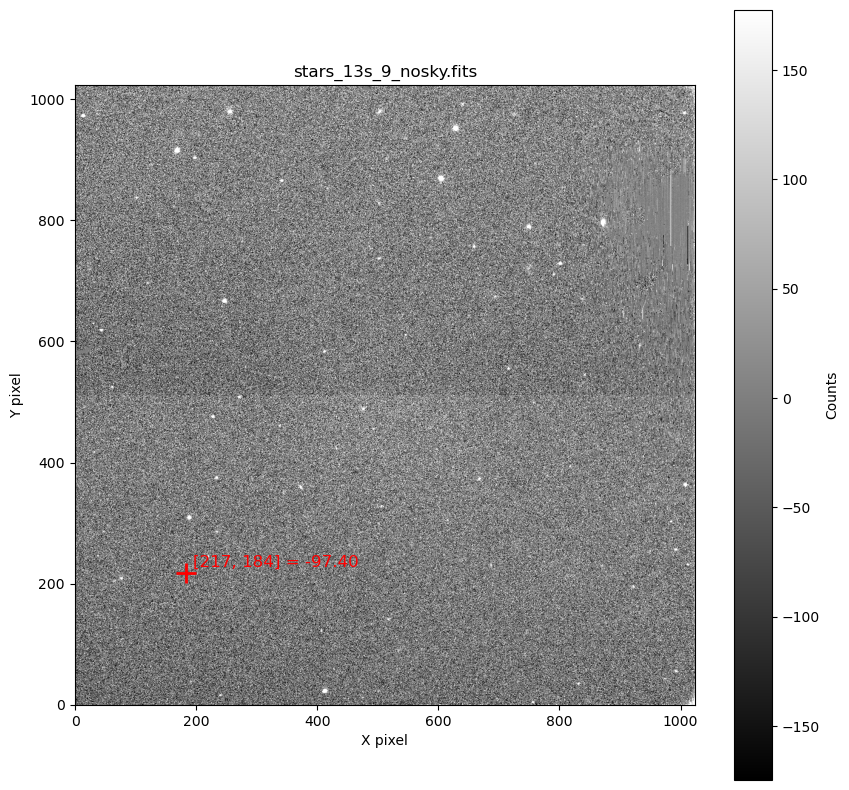

stars_13s_9_nosky.fits[217, 184] = -97.39643096923828
PROBLEM 2: Photometry Table with Star Positions

Frame offsets calculated from star 0:
Frame 0 -> Frame 1: dy = -2.0, dx = -37.0
Frame 0 -> Frame 2: dy = -30.0, dx = 33.0

Updated photometry table with all initial positions:
[[[698. 512.]
  [696. 475.]
  [668. 545.]]

 [[668. 520.]
  [666. 483.]
  [638. 553.]]

 [[568. 283.]
  [566. 246.]
  [538. 316.]]]
PROBLEM 3a: Gaussian Fitting for Star Positions and Widths

Star 0, Frame 0:
  Initial guess: y=698.0, x=512.0
  Fitted position: y=698.58, x=512.38
  Widths: sigma_y=1.05, sigma_x=0.96
  Average width: 1.01
  Fitted height: 2910.84
  Uncertainties: sigma_y_err=0.000, sigma_x_err=0.000

Star 0, Frame 1:
  Initial guess: y=696.0, x=475.0
  Fitted position: y=696.16, x=474.36
  Widths: sigma_y=1.02, sigma_x=0.97
  Average width: 0.99
  Fitted height: 1005.90
  Uncertainties: sigma_y_err=0.001, sigma_x_err=0.001

Star 0, Frame 2:
  Initial guess: y=668.0, x=545.0
  Fitted position: y=6

In [1]:
"""
Homework 10: Photometry
Patrick Kobrick
AST 5765/4762: Advanced Astronomical Data Analysis
Due: Wednesday Nov 12, 2:30pm

This script performs aperture photometry on stellar observations using the 
table generated in HW9 and the apphot function.
"""
# Imports
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from astropy.table import Table
import disk
from hw8_PKobrick import *
from hw9_PKobrick import *

In [3]:
# ============================================================================
# apphot function from previous homework
# ============================================================================

def apphot(image, mask, photrad, skyin, skyout, center):
    """Function that does aperture photometry on an image provided.
    
    Parameters
    ----------
    image : 2D array
        2D image that we want to do the photometry on
    mask : 2D array
        mask for bad pixels
    photrad : float
        radius for aperture photometry
    skyin : float
        inner radius of sky annulus
    skyout : float
        outer radius of sky annulus
    center : tuple
        tuple with center coordinates of star (y, x)
    
    Returns
    -------
    tuple
        tuple with stellar flux and average sky (per pixel) values
    """
    
    # I want to use part of the image around the star, not all of it:
    
    # define how many pixels my image needs to be
    nx = int(2*skyout + 1)
    ny = nx 
    
    # get the coordinates in the original image:
    y1 = int(np.max([0, np.floor(center[0] - ny/2)]))
    x1 = int(np.max([0, np.floor(center[1] - nx/2)]))
    y2 = int(np.min([image.shape[0], np.ceil(center[0] + ny/2)]))
    x2 = int(np.min([image.shape[1], np.ceil(center[1] + nx/2)]))
    
    # cut it out!
    imcut   = image[y1:y2, x1:x2].copy()
    maskcut = mask[y1:y2, x1:x2].copy()
    
    # Need to remember to update my central coordinates (of the star for photometry):
    cutcenter = (center[0] - y1, center[1] - x1)
    
    # need the shape of the new image for the disk.py too:
    shape = imcut.shape
    
    # Make the annulus + count
    skymask = disk.disk(skyout, cutcenter, shape) ^ disk.disk(skyin, cutcenter, shape)
    
    # average per pixel sky noise:
    skyav = np.sum(skymask * imcut) / np.sum(skymask)
    
    # Make the aperture + count
    apmask = disk.disk(photrad, cutcenter, shape)

    # CHANGED NOV 14TH (we already cut out the background. dont want to do it again to remove negitive sky values in final code)
    # Nov 14th I am still getting negitive values for my sky, im unsure as to why
    flux = np.sum(apmask * imcut)
    
    # Return your flux and average sky:
    return (flux, skyav)


# ============================================================================
# Problem 3: dophot function
# ============================================================================

def dophot(table, frames, mask, photrad, skyin, skyout):
    """Perform aperture photometry on all stars in all frames.
    
    This function runs apphot once per row of the input table and adds
    the resulting flux and sky values to the table.
    
    Parameters
    ----------
    table : numpy array or astropy Table
        Table from HW9 with shape (nstar, nframe, npar) containing
        star positions and Gaussian fit results. The array should have
        columns for: yguess, xguess, width, cy, cx, star, sky
    frames : 3D numpy array
        3D array of observational frames with shape (nframe, ny, nx)
    mask : 2D numpy array
        Mask for good/bad pixels (same shape as each frame)
    photrad : float
        Radius of photometry aperture (in pixels)
    skyin : float
        Inner radius of sky annulus (in pixels)
    skyout : float
        Outer radius of sky annulus (in pixels)
    
    Returns
    -------
    table : numpy array or astropy Table
        Input table with flux and sky columns filled in
    """
    
    # Get table dimensions
    nstar, nframe, npar = table.shape
    
    # Define column indices (from HW9)
    iyg, ixg, iwidth, icy, icx, istar, isky = np.arange(npar)
    
    # Loop through each star and each frame
    for star in range(nstar):
        for frame in range(nframe):
            # Get the center position from the Gaussian fit (cy, cx)
            cy = table[star, frame, icy]
            cx = table[star, frame, icx]
            
            # Skip if this star doesn't exist in this frame (NaN values)
            if np.isnan(cy) or np.isnan(cx):
                table[star, frame, istar] = np.nan
                table[star, frame, isky] = np.nan
                continue
            
            # Run aperture photometry
            center = (cy, cx)
            flux, skyav = apphot(frames[frame], mask, photrad, skyin, skyout, center)
            
            # Store results in the table
            table[star, frame, istar] = flux
            table[star, frame, isky] = skyav
    
    return table


# ============================================================================
# Main execution
# ============================================================================
print("=" * 70)
print("Homework 10: Aperture Photometry")
print("=" * 70)

# Photometry table with actual values from HW9
photometry = np.array(
[
#  yguess, xguess,     width,     cy,     cx,     star,     sky
# star 0
 [[   698,    512,    0.980, 698.62, 512.39,   np.nan,  np.nan],  # frame 0
  [   464,    517,    0.975, 464.37, 517.42,   np.nan,  np.nan],  # frame 1
  [   228,    522,    1.114, 228.43, 521.93,   np.nan,  np.nan]], # frame 2
# star 1
 [[   668,    520,    1.016, 667.88, 520.23,   np.nan,  np.nan],  # frame 0
  [   434,    525,    0.962, 433.58, 525.30,   np.nan,  np.nan],  # frame 1
  [   198,    530,    1.146, 197.64, 529.79,   np.nan,  np.nan]], # frame 2
# star 2
 [[   568,    283,    1.046, 568.26, 283.30,   np.nan,  np.nan],  # frame 0
  [   334,    288,    0.960, 333.96, 288.36,   np.nan,  np.nan],  # frame 1
  [    98,    293,    1.082,  98.07, 292.90,   np.nan,  np.nan]]  # frame 2
], dtype=float)

# Column indices
(iyg, ixg, iwidth, icy, icx, istar, isky) = np.arange(photometry.shape[2])
(nstar, nframe, npar) = photometry.shape

# Calculate aperture and sky annulus parameters
width = np.mean(photometry[:, :, iwidth])
aper = 3.0 * width   # this should enclose almost all flux
skyin = 5.0 * width  # far enough out not to get any significant flux
skyout = 8.0 * width # enclose several times more pixels than in aperture

print("\nPhotometry parameters:")
print(f"  Mean stellar width           : {width:.3f} pixels")
print(f"  Aperture radius              : {aper:.3f} pixels")
print(f"  Inner sky annulus radius     : {skyin:.3f} pixels")
print(f"  Outer sky annulus radius     : {skyout:.3f} pixels")

ny, nx = obj_array.shape[1], obj_array.shape[2]  # Get dimensions from obj_array
mask = np.ones((ny, nx), dtype=bool)  # True = good pixel, False = bad pixel

print("\nRunning aperture photometry...")
photometry = dophot(photometry, obj_array, mask, aper, skyin, skyout)

# Print results
print("\n" + "=" * 70)
print("Photometry Results:")
print("=" * 70)
print("# star frame   yg    xg   width    cy       cx      flux        sky")
for star in range(nstar):
    for frame in range(nframe):
        if not np.isnan(photometry[star, frame, icy]):
            print(f"# {star:d}    {frame:d}     {photometry[star, frame, iyg]:3.0f}  "
                  f"{photometry[star, frame, ixg]:3.0f}  {photometry[star, frame, iwidth]:.3f}  "
                  f"{photometry[star, frame, icy]:6.2f}  {photometry[star, frame, icx]:6.2f}  "
                  f"{photometry[star, frame, istar]:10.1f}  {photometry[star, frame, isky]:8.2f}")

# Save to ASCII file
output_filename = "hw10_PKobrick_photometry.txt"
print(f"\nSaving results to {output_filename}...")

# Create a formatted output
with open(output_filename, 'w') as f:
    f.write("# Aperture Photometry Results\n")
    f.write(f"# Aperture radius: {aper:.3f} pixels\n")
    f.write(f"# Sky annulus: {skyin:.3f} to {skyout:.3f} pixels\n")
    f.write("#\n")
    f.write("# star frame   yg    xg   width    cy       cx      flux        sky\n")
    for star in range(nstar):
        for frame in range(nframe):
            if not np.isnan(photometry[star, frame, icy]):
                f.write(f"{star:d} {frame:d} "
                        f"{photometry[star, frame, iyg]:7.1f} {photometry[star, frame, ixg]:7.1f} "
                        f"{photometry[star, frame, iwidth]:7.3f} "
                        f"{photometry[star, frame, icy]:8.2f} {photometry[star, frame, icx]:8.2f} "
                        f"{photometry[star, frame, istar]:12.1f} {photometry[star, frame, isky]:10.2f}\n")

print(f"Results saved to {output_filename}")

print("\n" + "=" * 70)
print("Script complete!")
print("=" * 70)

Homework 10: Aperture Photometry

Photometry parameters:
  Mean stellar width           : 1.031 pixels
  Aperture radius              : 3.094 pixels
  Inner sky annulus radius     : 5.156 pixels
  Outer sky annulus radius     : 8.250 pixels

Running aperture photometry...

Photometry Results:
# star frame   yg    xg   width    cy       cx      flux        sky
# 0    0     698  512  0.980  698.62  512.39     18881.0      0.77
# 0    1     464  517  0.975  464.37  517.42     18983.7    -11.01
# 0    2     228  522  1.114  228.43  521.93     16524.3    -17.25
# 1    0     668  520  1.016  667.88  520.23     43409.8     33.69
# 1    1     434  525  0.962  433.58  525.30     43088.2     -0.57
# 1    2     198  530  1.146  197.64  529.79     40168.3    -15.36
# 2    0     568  283  1.046  568.26  283.30     37865.1     42.92
# 2    1     334  288  0.960  333.96  288.36     35679.1      6.51
# 2    2      98  293  1.082   98.07  292.90     34109.6    -24.26

Saving results to hw10_PKobrick_ph